[*********************100%%**********************]  2 of 2 completed


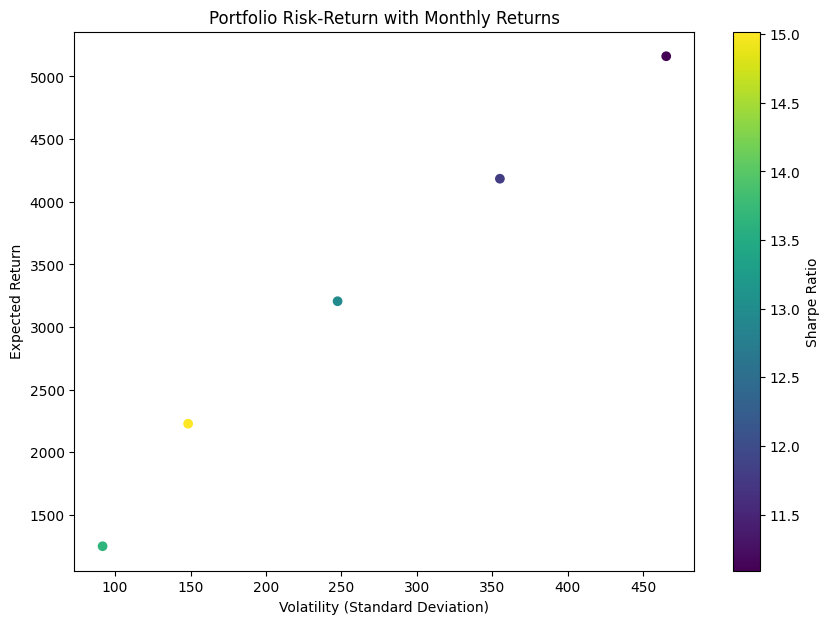

In [24]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Fetch historical data
data = yf.download(['GOOGL', 'NFLX'], start="2020-01-01", end="2023-01-01")['Adj Close']

# Calculate monthly returns
monthly_returns = data

# Annualize the monthly returns and calculate the covariance matrix
expected_monthly_returns = monthly_returns.mean() * 12  # approximating 12 months in a year
covariance_matrix_monthly = monthly_returns.cov() * 12  # approximating 12 months in a year

# Define the five different portfolio weight combinations
weights_combinations = [
    [1.0, 0.0],  # 100% NFLX
    [0.75, 0.25],  # 75% NFLX, 25% GOOGL
    [0.5, 0.5],  # 50% NFLX, 50% GOOGL
    [0.25, 0.75],  # 25% NFLX, 75% GOOGL
    [0.0, 1.0]  # 100% GOOGL
]

# Arrays to hold portfolio performances
portfolios_returns = []
portfolios_volatilities = []
sharpe_ratios = []

# Risk-free rate for Sharpe ratio, assuming 0 for simplicity
risk_free_rate = 0.0

# Calculate performance for each portfolio
for weights in weights_combinations:
    weights = np.array(weights)
    port_return = np.sum(weights * expected_monthly_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix_monthly, weights)))
    sharpe_ratio = (port_return - risk_free_rate) / port_volatility
    
    portfolios_returns.append(port_return)
    portfolios_volatilities.append(port_volatility)
    sharpe_ratios.append(sharpe_ratio)

# Convert lists to arrays for plotting
portfolios_returns = np.array(portfolios_returns)
portfolios_volatilities = np.array(portfolios_volatilities)
sharpe_ratios = np.array(sharpe_ratios)

# Plotting
plt.figure(figsize=(10, 7))
plt.scatter(portfolios_volatilities, portfolios_returns, c=sharpe_ratios, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.title('Portfolio Risk-Return with Monthly Returns')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.show()
